# Clifford Volume and Free-fermion Benchmark
## Bloqade Demonstration


The following packages are required to run this tutorial:
- `Bloqade`
- `Cirq`
Make sure these packages are installed in your Python environment.
If needed, you can install them via:
```bash
pip install bloqade cirq
```

In [28]:
# frontier benchmarks
from frontier import CliffordVolumeBenchmark, FreeFermionVolumeBenchmark

# bloqade
from bloqade import squin, qasm2
from bloqade.qasm2.emit import QASM2  # QASM2 target
from bloqade.qasm2.parse import pprint  # QASM2 pretty printer
from bloqade.pyqrack import StackMemorySimulator

# cirq
import cirq
from cirq.contrib.qasm_import import circuit_from_qasm
from bloqade.cirq_utils import load_circuit, noise

## Create Benchmark

In [2]:
# generate benchmark

n_qubits = 2
sample_size = 4
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="bloqade",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()


FreeFermion_benchmark = FreeFermionVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="bloqade",
    shots=shots,
    auto_save=False,
)

_ = FreeFermion_benchmark.create_benchmark()

Bloqade is a Python-based SDK for neutral-atom quantum computing. Built on top of Kirin (the Kernel Intermediate Representation Infrastructure), Bloqade adopts a kernel-oriented programming model. As a result, standard benchmark circuits must be translated into Bloqade-compatible kernels that explicitly capture the intended hardware execution.
Fortunately, the QASM2 dialect is already available and under active development. This allows us to convert a QASM2 string directly into the Bloqade dialect, providing a convenient path from standard circuit formats into Bloqade kernels.

## Convert QASM2 Programs into Bloqade Kernels

In [3]:
# let us itereate over all circuits in all samples

clifford_kernels = []
for sample in Clifford_benchmark.samples:
    for circuit in sample["circuits"]:
        cid = circuit["circuit_id"]
        qasm = circuit["qasm"] #  retrive the qasm program
        bloqade_kernel = qasm2.loads(qasm) # < -- initilaized kernel
        clifford_kernels.append(bloqade_kernel)

free_fermion_kernels = []
for sample in FreeFermion_benchmark.samples:
    for circuit in sample["circuits"]:
        cid = circuit["circuit_id"]
        qasm = circuit["qasm"]
        bloqade_kernel = qasm2.loads(qasm) # < -- initilaized kernel
        free_fermion_kernels.append(bloqade_kernel)


In [4]:
# the Bloqade kernel for the first Clifford Volume Benchmar circuit
clifford_kernels[0].print()

#and the corresponsing QASM2 program
print(Clifford_benchmark.get_all_circuits()[0])

func.func @main() -> !py.NoneType {
  ^0(%main_self):
  │  %0 = qasm2.expr.constant.int 2 : !py.int
  │  %1 = qasm2.core.qreg.new(n_qubits=%0) : !py.IList[!py.Qubit, !Any]
  │  %2 = qasm2.expr.constant.int 2 : !py.int
  │  %3 = qasm2.core.creg.new(n_bits=%2) : !py.CReg
  │  %4 = qasm2.expr.constant.int 1 : !py.int
  │  %5 = qasm2.core.qreg.get(reg=%1, idx=%4) : !py.Qubit
  │  %6 = qasm2.expr.constant.int 0 : !py.int
  │  %7 = qasm2.core.qreg.get(reg=%1, idx=%6) : !py.Qubit
  │       qasm2.uop.CX(ctrl=%5, qarg=%7)
  │  %8 = qasm2.expr.constant.int 0 : !py.int
  │  %9 = qasm2.core.qreg.get(reg=%1, idx=%8) : !py.Qubit
  │ %10 = qasm2.expr.constant.int 1 : !py.int
  │ %11 = qasm2.core.qreg.get(reg=%1, idx=%10) : !py.Qubit
  │       qasm2.uop.CX(ctrl=%9, qarg=%11)
  │ %12 = qasm2.expr.constant.int 1 : !py.int
  │ %13 = qasm2.core.qreg.get(reg=%1, idx=%12) : !py.Qubit
  │ %14 = qasm2.expr.constant.int 0 : !py.int
  │ %15 = qasm2.core.qreg.get(reg=%1, idx=%14) : !py.Qubit
  │       qasm2.uop.

The Bloqade kernels can be easily converted back to a QAMS2 progmram.

In [5]:
target = QASM2()
ast = target.emit(clifford_kernels[0])
pprint(ast)

OPENQASM 2.0;
include "qelib1.inc";
qreg var_0[2];
creg var_1[2];
CX var_0[1], var_0[0];
CX var_0[0], var_0[1];
CX var_0[1], var_0[0];
s var_0[0];
h var_0[0];
s var_0[0];
h var_0[1];
CX var_0[0], var_0[1];
h var_0[1];
CX var_0[1], var_0[0];
h var_0[1];
h var_0[0];
h var_0[1];
s var_0[0];
s var_0[0];
s var_0[1];
s var_0[1];
h var_0[0];
h var_0[1];
s var_0[0];
s var_0[0];
h var_0[1];
measure var_0[0] -> var_1[0];
measure var_0[1] -> var_1[1];


## Simulation

Bloqade also includes emulator backends for simulating quantum circuits. In particular, the PyQrack simulator is integrated into the Bloqade toolchain, allowing us to execute and validate our benchmark circuits without requiring access to physical hardware.

In [6]:
#initialize the simulator backend

# the PyQcrack provide a statevector simulator
sim = StackMemorySimulator(min_qubits=2)

state = sim.state_vector(clifford_kernels[0]) #compute the state of the system afte the first clifford volume benchmark circuits
print(state)

[(-0+0j), (-0.688792884349823+0.7249581813812256j), 0j, 0j]


Simulating more realistic scenarios requires the use of noise models and count-based evaluation. While the integrated PyQrack backend is capable of supporting such simulations, the current implementation of the QASM2 dialect does not yet automatically generate kernels that return measured classical results. Consequently, it cannot be directly used for our benchmark workflow in its present form.
To address this limitation, we introduce an intermediate step using the Cirq SDK. Bloqade is already compatible with Cirq circuits, enabling proper convertion into the kernel pipeline. This workaround allows us to demonstrate the benchmarking pipeline using Bloqade together with our framework.

In [7]:
# generate benchmark

n_qubits = 5
sample_size = 1
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()


FreeFermion_benchmark = FreeFermionVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)

_ = FreeFermion_benchmark.create_benchmark()

In [8]:
circuit = Clifford_benchmark.samples[0]["circuits"][0]["qasm"]  # first benchmark circuit

circuit = circuit_from_qasm(circuit)  # convert the QASM string to a Cirq circuit

# Cirq circuits can be lowered to a custom SQUIN kernel
apply_cirq = load_circuit(
    circuit,
    register_as_argument=True,
    kernel_name="apply_cirq"
)

# number of qubits in the benchmark
n = Clifford_benchmark.number_of_qubits

# create the corresponding Bloqade kernel manually using the SQUIN dialect
@squin.kernel
def main():
    # allocate the quantum register
    qreg = squin.qalloc(n)

    # apply the benchmark circuit to the quantum register
    apply_cirq(qreg)

    # return classical bits storing the measurement results
    return squin.broadcast.measure(qreg)

# create the simulator backend
sim = StackMemorySimulator(min_qubits=n)

# create a task for simulating/evaluating the current kernel
task = sim.task(main)

# compute shot counts
raw = task.batch_run(shots=Clifford_benchmark.shots)

print(raw)

{(<Measurement.Zero: 0>, <Measurement.Zero: 0>, <Measurement.Zero: 0>, <Measurement.One: 1>, <Measurement.One: 1>): 0.2705078125, (<Measurement.Zero: 0>, <Measurement.One: 1>, <Measurement.One: 1>, <Measurement.One: 1>, <Measurement.Zero: 0>): 0.2705078125, (<Measurement.Zero: 0>, <Measurement.One: 1>, <Measurement.Zero: 0>, <Measurement.Zero: 0>, <Measurement.One: 1>): 0.2412109375, (<Measurement.Zero: 0>, <Measurement.Zero: 0>, <Measurement.One: 1>, <Measurement.Zero: 0>, <Measurement.Zero: 0>): 0.2177734375}


PyQrack uses its own format for measurement counts, so we need a simple conversion function to transform the results into a more standard format.

In [9]:
def bloqade_counts_to_bitstrings(raw_counts, *, reverse=False, shots = 1024):
    """
    Convert Bloqade Measurement tuple keys → bitstring keys.

    reverse=True if you want little-endian display.
    """
    out = {}

    for outcome, value in raw_counts.items():
        bits = []

        for m in outcome:
            # works for Measurement enum
            try:
                b = int(m)
            except Exception:
                # fallback: check name
                b = 1 if "One" in str(m) else 0
            bits.append(str(b))

        if reverse:
            bits = bits[::-1]

        bitstring = "".join(bits)
        out[bitstring] = int(shots*value)

    return out

In [10]:
# run simulation for all circuits

clifford_counts = [] # <-- collect the counts for the CFV benchmark

circuits = Clifford_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)  

    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        circuit,
        register_as_argument=True,
        kernel_name="apply_cirq"
    )
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    clifford_counts.append(bloqade_counts_to_bitstrings(raw))

In [11]:
# run simulation for all circuits

freefermion_counts = [] # <-- collect the counts for the CFV benchmark

circuits = FreeFermion_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)  

    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        circuit,
        register_as_argument=True,
        kernel_name="apply_cirq"
    )
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    freefermion_counts.append(bloqade_counts_to_bitstrings(raw))

### Attach simulated results to the benchmark object

In [12]:
Clifford_benchmark.add_experimental_results(
    clifford_counts,
    experiment_id="bloqade_clifford_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)


FreeFermion_benchmark.add_experimental_results(
    freefermion_counts,
    experiment_id="bloqade_free_fermion_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)

### Evaluate and plot benchmark


 Clifford Benchmark Evaluation (5 qubits)
Thresholds: τ_S = 1/e = 0.367879   τ_D = 1/(2e) = 0.183940
Shots per circuit: 1024
--------------------------------------------------------------
Stabilizers (all measured):
  • mean ± std: 1.000000 ± 0.000000
  • min EV:     1.000000
Destabilizers (all measured):
  • mean ± std: -0.016602 ± 0.018033
  • max |EV|:   0.035156
--------------------------------------------------------------
Per-sample pass count: 1/1
Worst stabilizer margin (min over samples of <S>-2σ): sample 0 -> 1.000000
Worst destabilizer margin (max over samples of |<D>|+2σ): sample 0 -> 0.097618
Benchmark passed (all samples): True



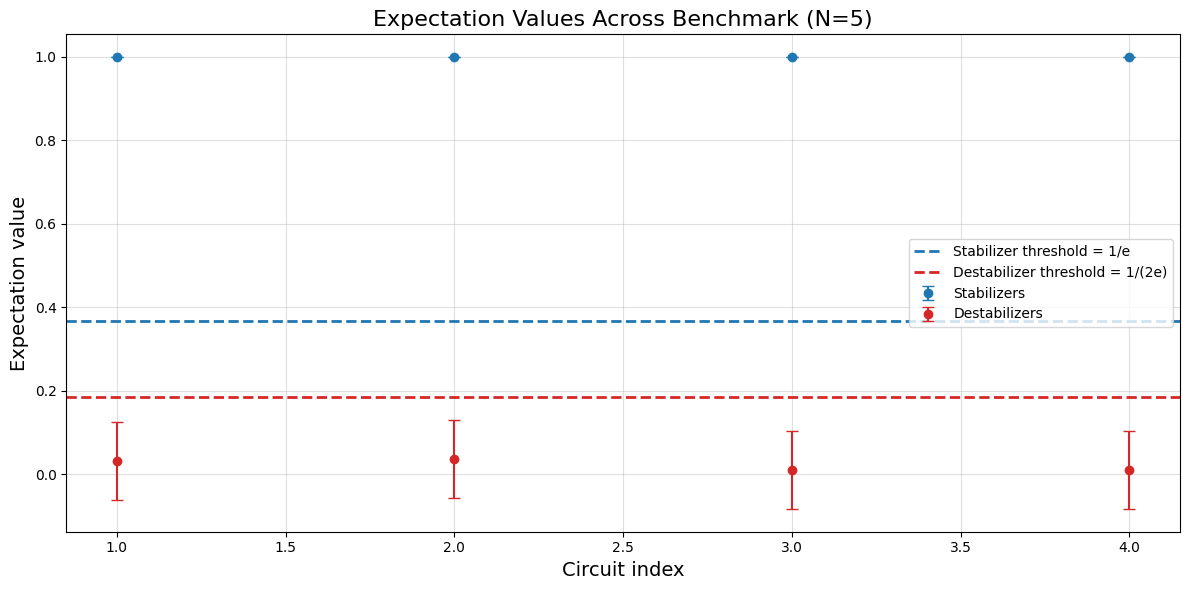

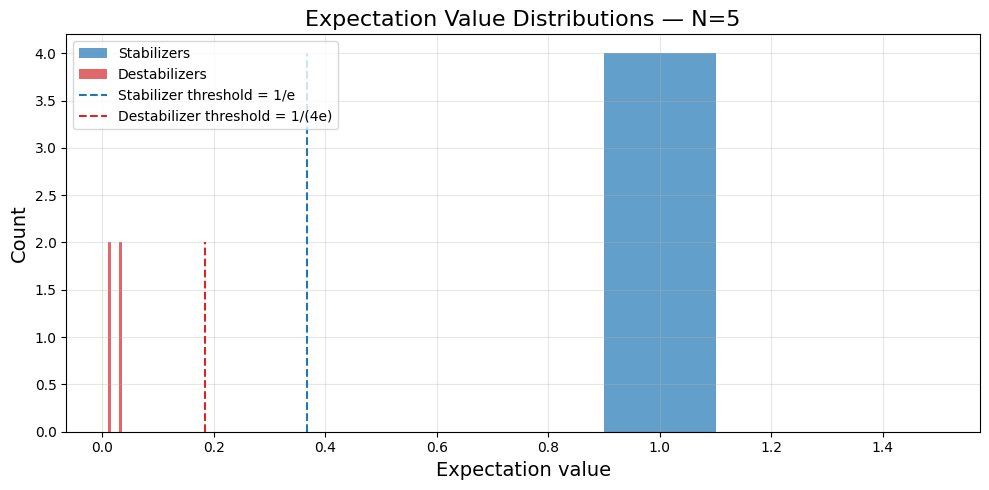

In [13]:
# Clifford Volume
evaluation = Clifford_benchmark.evaluate_benchmark()
Clifford_benchmark.plot_all_expectation_values()
Clifford_benchmark.plot_expectation_histograms(bins=5)


 Free-Fermion Benchmark Evaluation (5 qubits)

Parallel projected values (should be near 1):
  • average: 0.992602 ± 0.000000
  • lowest measured value: 0.992602

Orthogonal projected values (should be near 0):
  • average: 0.005039 ± 0.000000
  • highest absolute value: 0.005039


Benchmark passed: True



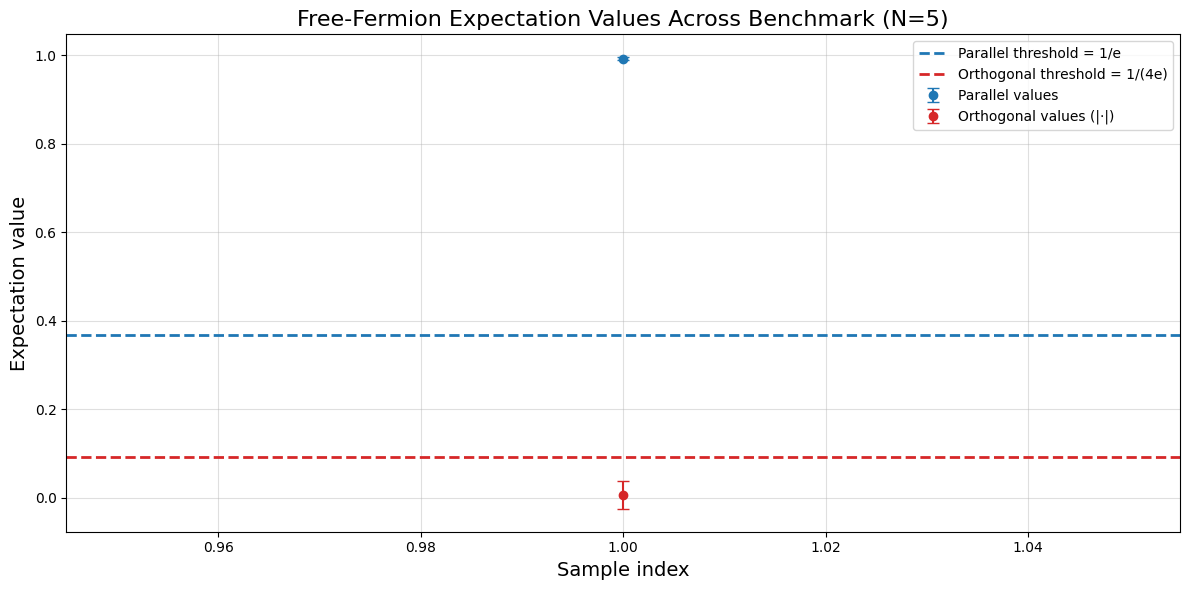

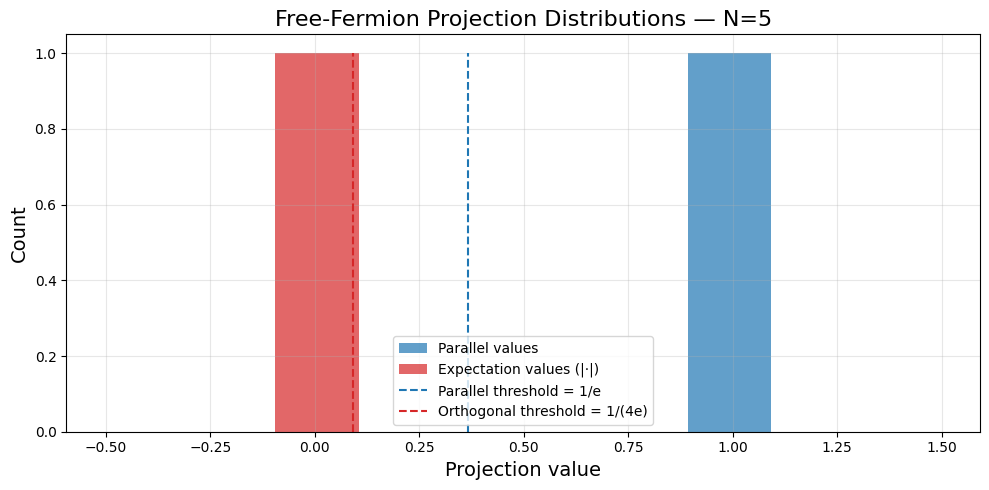

In [14]:
# Free-fermion Volume
evaluation = FreeFermion_benchmark.evaluate_benchmark()
FreeFermion_benchmark.plot_all_expectation_values()
FreeFermion_benchmark.plot_expectation_histograms(bins=5)

### Noisy simulator
Bloqade makes it possible to inject gate-level noise directly into the circuit. We use a noise model similar to our previous approach, applying a two-qubit depolarization channel to model gate errors. In Bloqade, this noise can be inserted directly within the defined kernel.


In [15]:

# define circuit transformation to inlcude noise chanels
def add_twoq_depolarizing_noise(circuit, p2):
    noisy_ops = []

    for op in circuit.all_operations():
        noisy_ops.append(op)

        # if this is a 2-qubit gate → add noise
        if len(op.qubits) == 2:
            q0, q1 = op.qubits
            noisy_ops.append(cirq.depolarize(p2).on(q0))
            noisy_ops.append(cirq.depolarize(p2).on(q1))

    return cirq.Circuit(noisy_ops)

In [16]:
# the workflow is the same as before
# generate benchmark

n_qubits = 5
sample_size = 1
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="qiskit",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()


FreeFermion_benchmark = FreeFermionVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="qiskit",
    shots=shots,
    auto_save=False,
)

_ = FreeFermion_benchmark.create_benchmark()

In [17]:
p2 = 0.01  # choose the two-qubit gate error rate

In [18]:
# run simulation for all circuits

clifford_counts = [] # <-- collect the counts for the CFV benchmark

circuits = Clifford_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)
    
    # inject per-gate noise 
    circuit = add_twoq_depolarizing_noise(circuit, p2)

    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        circuit,
        register_as_argument=True,
        kernel_name="apply_cirq"
    )
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    clifford_counts.append(bloqade_counts_to_bitstrings(raw))

In [19]:
# run simulation for all circuits

freefermion_counts = [] # <-- collect the counts for the CFV benchmark

circuits = FreeFermion_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)
    
    # inject per-gate noise 
    circuit = add_twoq_depolarizing_noise(circuit, p2)

    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        circuit,
        register_as_argument=True,
        kernel_name="apply_cirq"
    )
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    freefermion_counts.append(bloqade_counts_to_bitstrings(raw))


In [20]:
Clifford_benchmark.add_experimental_results(
    clifford_counts,
    experiment_id="bloqade_clifford_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)


FreeFermion_benchmark.add_experimental_results(
    freefermion_counts,
    experiment_id="bloqade_free_fermion_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)


 Clifford Benchmark Evaluation (5 qubits)
Thresholds: τ_S = 1/e = 0.367879   τ_D = 1/(2e) = 0.183940
Shots per circuit: 1024
--------------------------------------------------------------
Stabilizers (all measured):
  • mean ± std: 0.692871 ± 0.020079
  • min EV:     0.671875
Destabilizers (all measured):
  • mean ± std: 0.014648 ± 0.026940
  • max |EV|:   0.041016
--------------------------------------------------------------
Per-sample pass count: 1/1
Worst stabilizer margin (min over samples of <S>-2σ): sample 0 -> 0.625583
Worst destabilizer margin (max over samples of |<D>|+2σ): sample 0 -> 0.103463
Benchmark passed (all samples): True



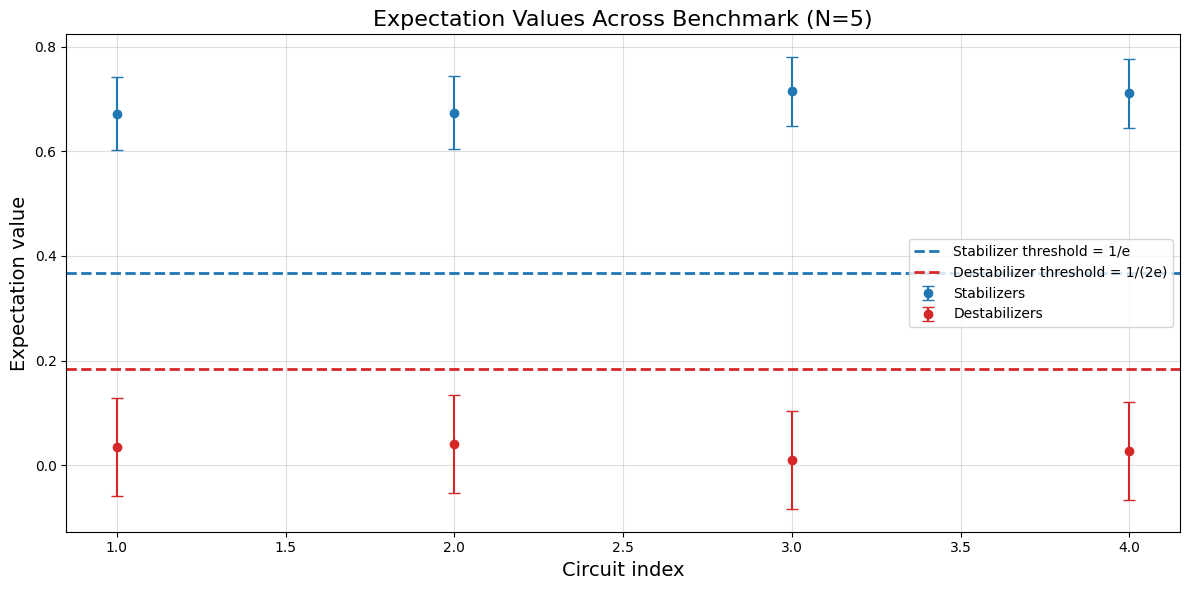

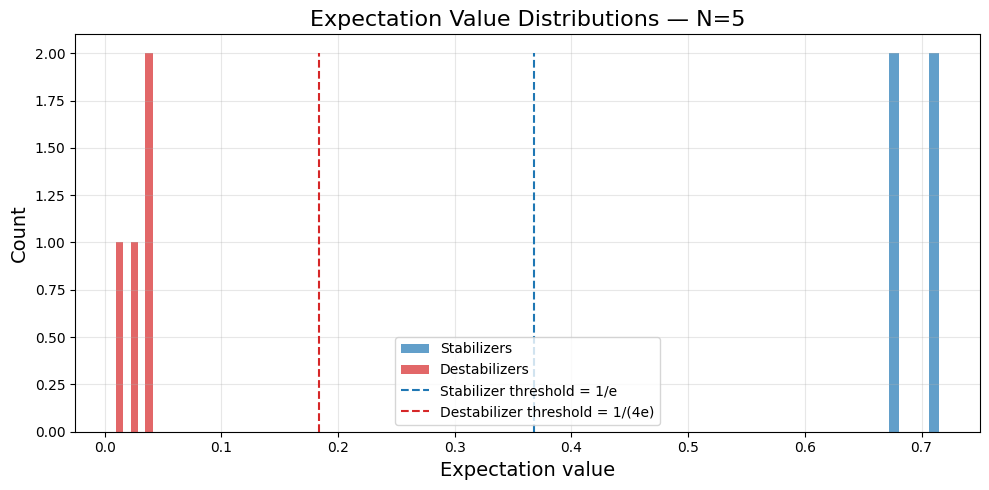

In [21]:
# Clifford Volume
evaluation = Clifford_benchmark.evaluate_benchmark()
Clifford_benchmark.plot_all_expectation_values()
Clifford_benchmark.plot_expectation_histograms(bins=5)


 Free-Fermion Benchmark Evaluation (5 qubits)

Parallel projected values (should be near 1):
  • average: 0.497938 ± 0.000000
  • lowest measured value: 0.497938

Orthogonal projected values (should be near 0):
  • average: -0.031391 ± 0.000000
  • highest absolute value: 0.031391


Benchmark passed: True



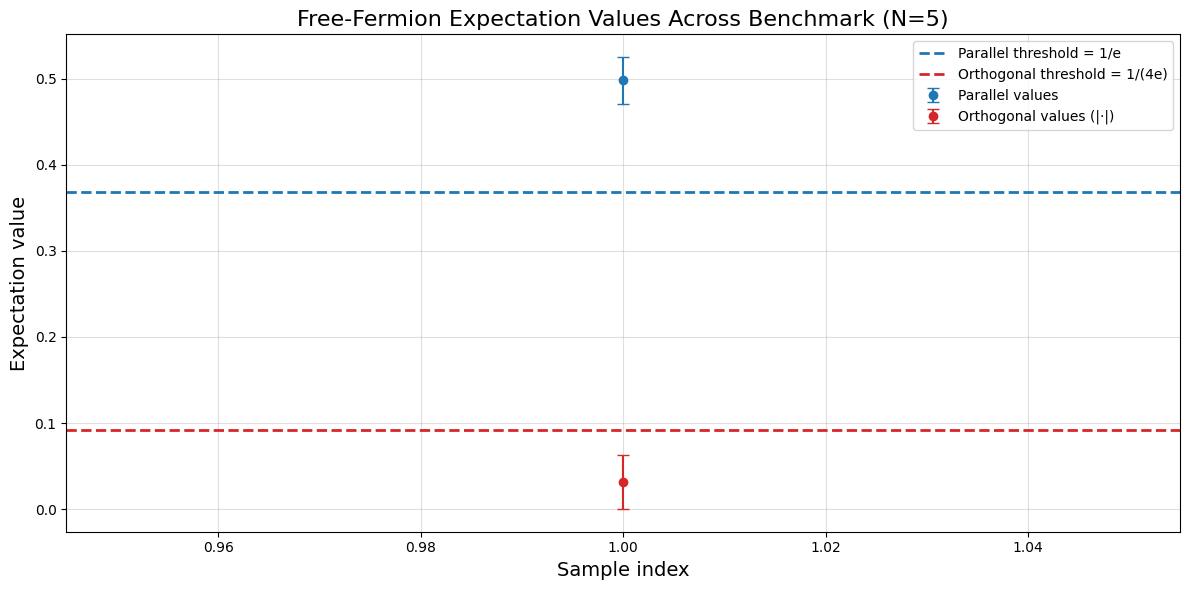

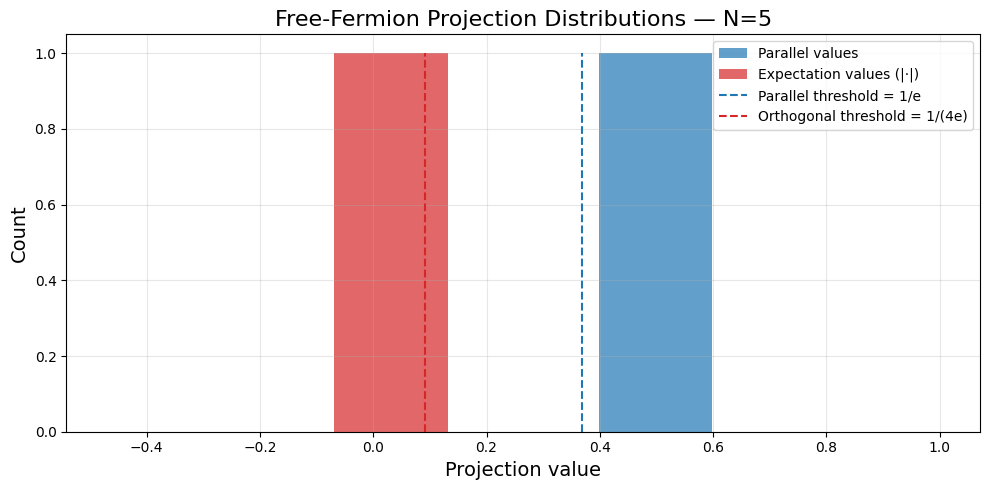

In [22]:
# Free-fermion Volume
evaluation = FreeFermion_benchmark.evaluate_benchmark()
FreeFermion_benchmark.plot_all_expectation_values()
FreeFermion_benchmark.plot_expectation_histograms(bins=5)

The combination of Bloqade and Cirq enables the use of more realistic neutral-atom error models. In our workflow, we apply the GeminiOneZoneNoiseModel, a Cirq-compatible noise model that approximates Gemini-class hardware under a single-zone assumption, where all qubits remain in the gate region throughout the computation.

In [23]:
# run simulation for all circuits

clifford_counts = [] # <-- collect the counts for the CFV benchmark

circuits = Clifford_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)

    # add Gemini noise in Cirq
    noisy = noise.transform_circuit(
        circuit,
        model=noise.GeminiOneZoneNoiseModel(),
        parallelize_circuit=False,
    )

    
    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        noisy, 
        register_as_argument=True, 
        kernel_name="apply_cirq"
    )
    
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    clifford_counts.append(bloqade_counts_to_bitstrings(raw))

In [24]:
# run simulation for all circuits

freefermion_counts = [] # <-- collect the counts for the CFV benchmark

circuits = FreeFermion_benchmark.get_all_circuits()

for qasm_str in circuits:
    # convert the QASM string to a Cirq circuit
    circuit = circuit_from_qasm(qasm_str)
    
    # add Gemini noise in Cirq
    noisy = noise.transform_circuit(
        circuit,
        model=noise.GeminiOneZoneNoiseModel(),
        parallelize_circuit=False,
    )

    # Cirq circuits can be lowered to a custom SQUIN kernel
    apply_cirq = load_circuit(
        noisy, 
        register_as_argument=True, 
        kernel_name="apply_cirq"
    )
    
    # number of qubits in the benchmark
    n = Clifford_benchmark.number_of_qubits
    
    # create the corresponding Bloqade kernel manually using the SQUIN dialect
    @squin.kernel
    def main():
        # allocate the quantum register
        qreg = squin.qalloc(n)
    
        # apply the benchmark circuit to the quantum register
        apply_cirq(qreg)
    
        # return classical bits storing the measurement results
        return squin.broadcast.measure(qreg)
    
    # create the simulator backend
    sim = StackMemorySimulator(min_qubits=n)
    
    # create a task for simulating/evaluating the current kernel
    task = sim.task(main)
    
    # compute shot counts
    raw = task.batch_run(shots=Clifford_benchmark.shots)
    
    freefermion_counts.append(bloqade_counts_to_bitstrings(raw))


In [25]:
Clifford_benchmark.add_experimental_results(
    clifford_counts,
    experiment_id="bloqade_clifford_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)


FreeFermion_benchmark.add_experimental_results(
    freefermion_counts,
    experiment_id="bloqade_free_fermion_demo",
    platform="Bloqade",
    experiment_metadata={"backend": "PyQrack"},
)


 Clifford Benchmark Evaluation (5 qubits)
Thresholds: τ_S = 1/e = 0.367879   τ_D = 1/(2e) = 0.183940
Shots per circuit: 1024
--------------------------------------------------------------
Stabilizers (all measured):
  • mean ± std: 0.595215 ± 0.035329
  • min EV:     0.537109
Destabilizers (all measured):
  • mean ± std: 0.005371 ± 0.009704
  • max |EV|:   0.015625
--------------------------------------------------------------
Per-sample pass count: 1/1
Worst stabilizer margin (min over samples of <S>-2σ): sample 0 -> 0.484390
Worst destabilizer margin (max over samples of |<D>|+2σ): sample 0 -> 0.078117
Benchmark passed (all samples): True



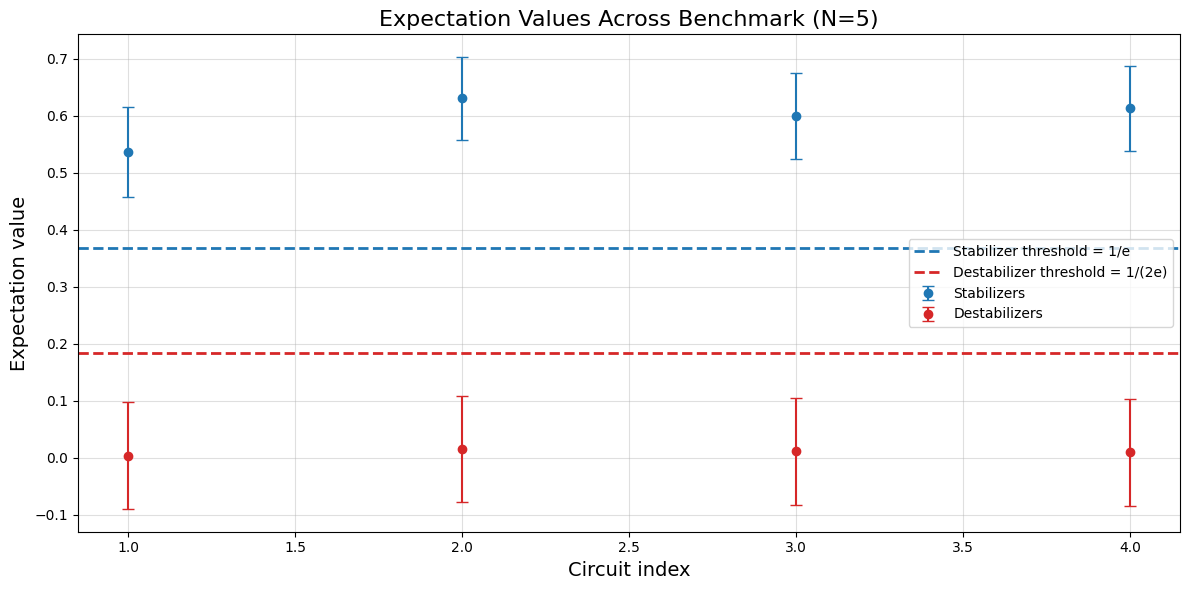

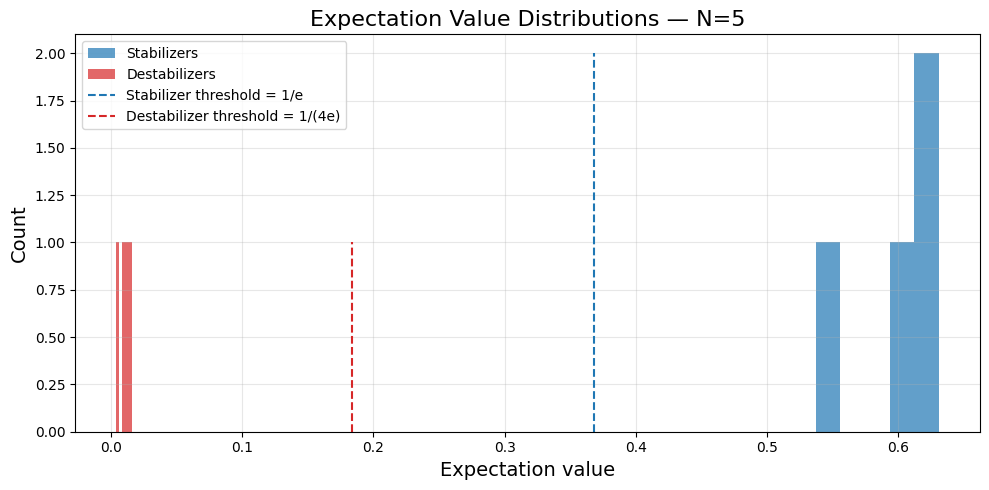

In [26]:
# Clifford Volume
evaluation = Clifford_benchmark.evaluate_benchmark()
Clifford_benchmark.plot_all_expectation_values()
Clifford_benchmark.plot_expectation_histograms(bins=5)


 Free-Fermion Benchmark Evaluation (5 qubits)

Parallel projected values (should be near 1):
  • average: 0.271606 ± 0.000000
  • lowest measured value: 0.271606

Orthogonal projected values (should be near 0):
  • average: 0.005733 ± 0.000000
  • highest absolute value: 0.005733


Benchmark passed: False



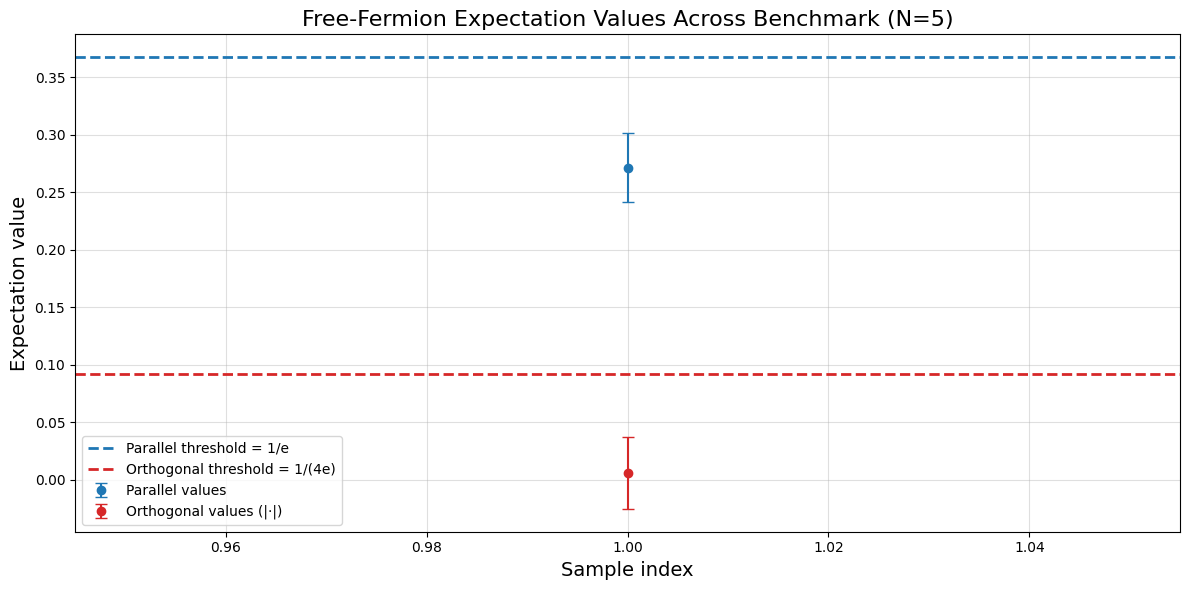

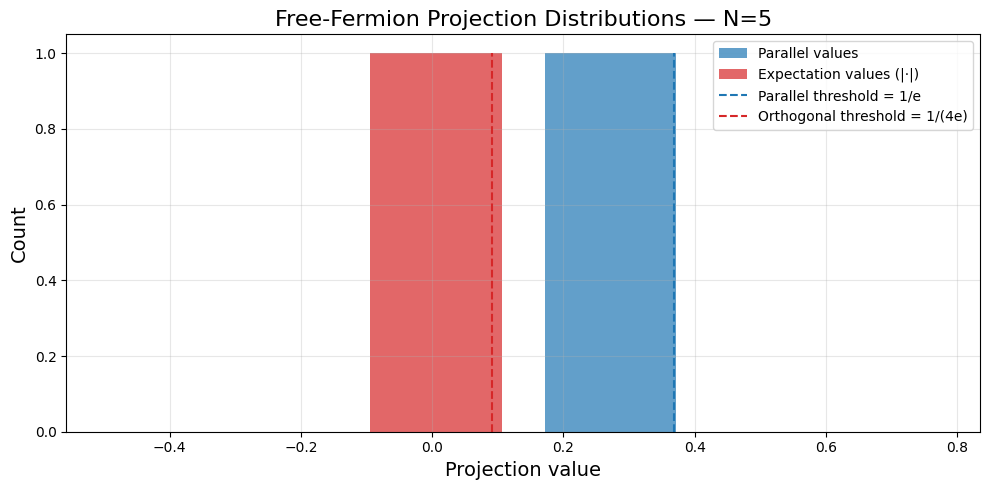

In [27]:
# Free-fermion Volume
evaluation = FreeFermion_benchmark.evaluate_benchmark()
FreeFermion_benchmark.plot_all_expectation_values()
FreeFermion_benchmark.plot_expectation_histograms(bins=5)

# Execute benchmark on real hardware
At present, Bloqade primarily supports real-device execution for analog neutral-atom programs. The digital gate-based workflow used in this demo is therefore best validated via simulation. Once hardware support for gate-based computation matures, we plan to complete this demonstration on real devices.